In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [12]:
# 1. Generate dataset (binary classification, 2 features)
X, y = make_classification(
    n_samples=1000, 
    n_features=2, 
    n_redundant=0, 
    n_informative=2, 
    n_clusters_per_class=1, 
    random_state=42
)

print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


In [13]:
X[:5]

array([[ 0.60103418,  1.5353525 ],
       [ 0.75594526, -1.1723519 ],
       [ 1.35447877, -0.94852841],
       [ 3.1030897 ,  0.23348484],
       [ 0.75317779,  0.78751427]])

In [14]:
y[:5]

array([1, 0, 0, 0, 1])

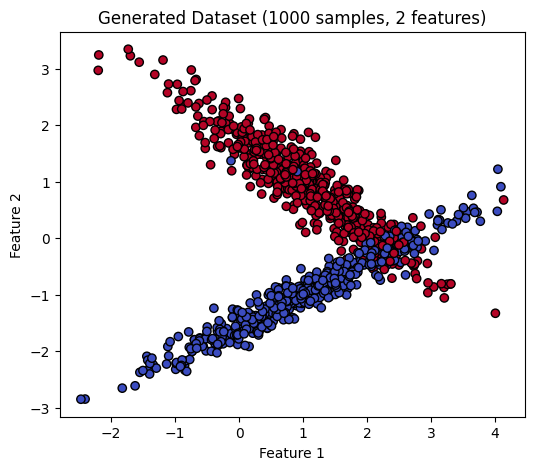

In [15]:
# 2. Plot dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
plt.title("Generated Dataset (1000 samples, 2 features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [16]:
# 3. Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train SVM
svm_model = SVC(kernel='linear') ## you can use linear, rbf and poly kernels
svm_model.fit(X_train, y_train)

rf_clf = RandomForestClassifier(n_estimators=3)
rf_clf.fit(X_train, y_train)

,n_estimators,3
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
# 5. Predictions
y_pred = svm_model.predict(X_test)
y_pred_rf = rf_clf.predict(X_test)

# 6. Evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("📊 Model Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


print("📊 Model Evaluation Metrics:")
print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")


📊 Model Evaluation Metrics:
Accuracy:  0.9250
Precision: 0.9880
Recall:    0.8542
F1 Score:  0.9162
📊 Model Evaluation Metrics:
Accuracy:  0.9300
Precision: 0.9184
Recall:    0.9375
F1 Score:  0.9278


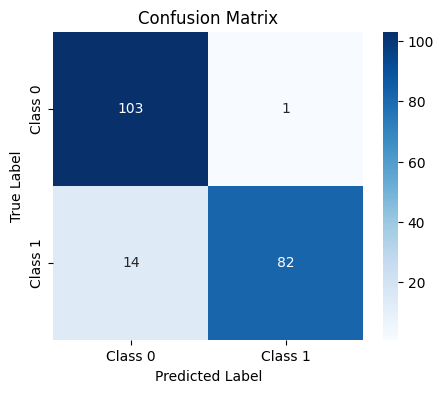

In [18]:
# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

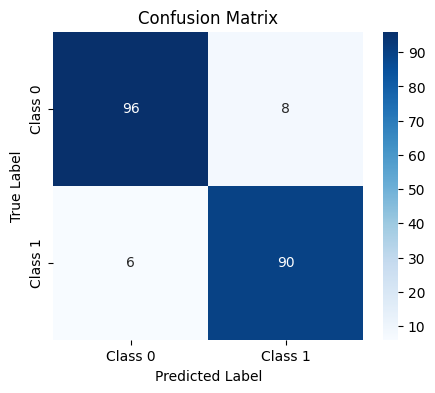

In [19]:
# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

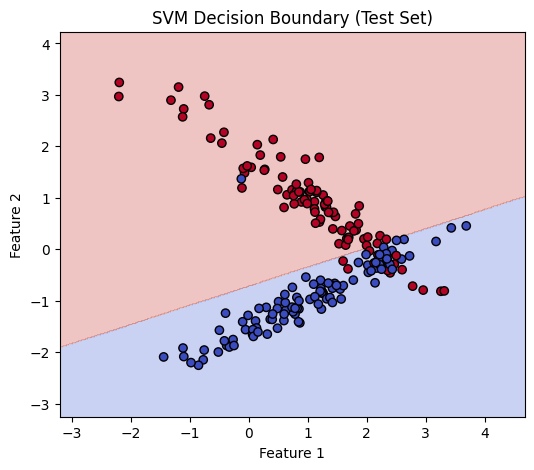

In [9]:
# 8. Plot decision boundaries
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    h = 0.02  # step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(svm_model, X_test, y_test, "SVM Decision Boundary (Test Set)")


## **SVM From Scratch**

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Generate dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


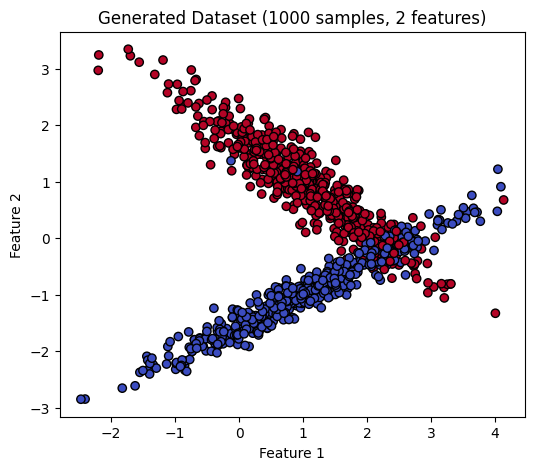

In [46]:
# 2. Plot dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
plt.title("Generated Dataset (1000 samples, 2 features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [47]:
y[:10]

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1])

In [48]:
# Convert labels from {0,1} to {-1,+1} (required for SVM hinge loss)
y = np.where(y == 0, -1, 1)

# 2. Train-test split
split_ratio = 0.8
n_train = int(split_ratio * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

print(y[:10])
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

[ 1 -1 -1 -1  1  1 -1  1  1  1]
(800, 2)
(800,)
(200, 2)
(200,)


In [49]:
import numpy as np

w = np.zeros(X_train.shape[1])   # weights
b = 0.0                          # bias
lr = 0.001                       # learning rate
epochs = 2000                    # iterations
C = 5                        # regularization strength 

## Training loop (SGD on hinge loss)
for epoch in range(epochs):
    for i in range(len(X_train)):
        condition = y_train[i] * (np.dot(X_train[i], w) + b) >= 1
        
        if condition:
            # Hinge loss inactive → only regularizer contributes
            dw = w                 # gradient of (1/2)*||w||^2
            db = 0
        else:
            # Hinge loss active → regularizer + penalty term
            dw = w - C * y_train[i] * X_train[i]
            db = -C * y_train[i]
        
        # Parameter updates
        w = w - lr * dw
        b = b - lr * db


In [50]:
# 5. Predictions
y_pred = np.sign(np.dot(X_test, w) + b)

# Convert back {-1,+1} → {0,1} for metrics
y_test_metrics = np.where(y_test == -1, 0, 1)
y_pred_metrics = np.where(y_pred == -1, 0, 1)

# 6. Evaluation
acc = accuracy_score(y_test_metrics, y_pred_metrics)
prec = precision_score(y_test_metrics, y_pred_metrics)
rec = recall_score(y_test_metrics, y_pred_metrics)
f1 = f1_score(y_test_metrics, y_pred_metrics)

print("📊 Model Evaluation (Scratch SVM)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")


📊 Model Evaluation (Scratch SVM)
Accuracy:  0.9200
Precision: 0.9355
Recall:    0.8969
F1 Score:  0.9158


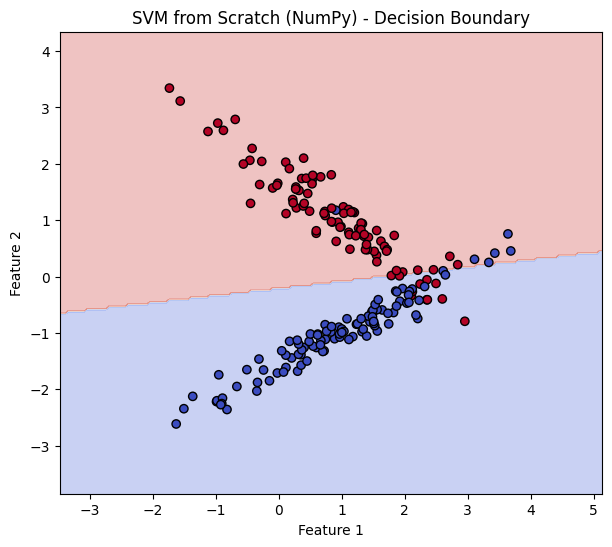

In [51]:
# 7. Plot decision boundary
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = np.sign(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors="k")
plt.title("SVM from Scratch (NumPy) - Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

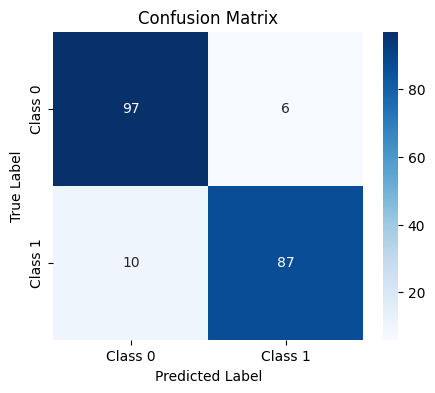

In [52]:
# 7. Confusion Matrix
cm = confusion_matrix(y_test_metrics, y_pred_metrics)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()